# MISP API — Live Jupyter Demo
### Kraven Security · MISP Series

---
> **Run order matters**: Section 3 creates an event whose `id` is reused in later cells.
A cleanup cell at the bottom deletes the demo event so the instance resets between takes.

## ⚙️ Config & dependencies

API key is read from the `MISP_KEY` environment variable — **never hard-code a key in a notebook you're streaming.**
Set it before launching Jupyter:

```bash
export MISP_KEY="your-throwaway-key"      # macOS / Linux
# setx MISP_KEY "your-throwaway-key"      # Windows (new terminal after)
```

In [ ]:
# One-time install (run off-air). Uncomment if needed.
%pip install pymisp pandas requests dotenv prettyprint matplotlib

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()  # loads .env from the current directory, where we put our MISP_KEY
MISP_URL    = "https://docker01"          # your throwaway instance
MISP_KEY    = os.environ["MISP_KEY"]       # loaded from env, not shown on screen
MISP_VERIFY = False                        # self-signed cert on the lab VM

# Quietly created later by Section 3; declared here so cleanup never NameErrors.
created = None

---
## 1. Setup & First Contact
*PyMISP, auth, and the object model*

PyMISP is the official Python wrapper around MISP's REST API. Everything it does, it does
by calling REST under the hood — we prove that in the appendix.

In [2]:
from pymisp import PyMISP
import urllib3
urllib3.disable_warnings()   # throwaway instance uses a self-signed cert

misp = PyMISP(MISP_URL, MISP_KEY, MISP_VERIFY)
misp.misp_instance_version   # connection sanity check

{'version': '2.5.36',
 'pymisp_recommended_version': '2.5.33.1',
 'perm_sync': True,
 'perm_sighting': True,
 'perm_galaxy_editor': True,
 'perm_analyst_data': True,
 'uuid': 'de8043d8-fe67-4c2d-b432-d113c22dd9a1',
 'request_encoding': ['gzip', 'br', 'zstd'],
 'filter_sightings': True}

**The object model bridge:** an *Event* in the UI is a `MISPEvent` here; an *Attribute*
is `add_attribute()`; an *Object* is a `MISPObject`. Same data model you already know — just code.

*Pitfalls:* `403` = wrong/expired key · SSL errors = the `verify=False` flag ·
if `misp_instance_version` misbehaves, fall back to `misp.get_version()`.

---
## 2. Search & Read
*Querying events, attributes, and IOCs — the workhorse*

In [4]:
# The 80% use case: recent network IOCs flagged for detection (to_ids=True)
results = misp.search(
    controller='attributes',
    type_attribute=['ip-src', 'ip-dst', 'domain', 'url'],
    to_ids=True,
    date_from='30d',          # MISP understands relative time
    pythonify=True            # return MISPAttribute objects, not raw JSON
)

print(f"{len(results)} attributes matched\n")
for attr in results[:-10]:
    print(f"{attr.type:10} {attr.value:35.35} <- {attr.Event.info}")

61610 attributes matched

domain     world-new-iope.cc                   <- Maltrail IOC for 2026-04-09
domain     volimor.com                         <- Maltrail IOC for 2026-04-09
domain     app.rustture.cc                     <- Maltrail IOC for 2026-04-09
domain     gatuso.duckdns.org                  <- Maltrail IOC for 2026-04-09
domain     vmail.wiki                          <- Maltrail IOC for 2026-04-09
domain     shootr.cyou                         <- Maltrail IOC for 2026-04-09
domain     noto.space                          <- Maltrail IOC for 2026-04-09
domain     notospace.com                       <- Maltrail IOC for 2026-04-09
domain     docs.noto.space                     <- Maltrail IOC for 2026-04-09
ip-dst     91.208.197.241                      <- Maltrail IOC for 2026-04-09
ip-dst     45.88.186.147                       <- Maltrail IOC for 2026-04-09
ip-dst     144.31.165.210                      <- Maltrail IOC for 2026-04-09
ip-dst     144.31.165.219             

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import pandas as pd

# ── Gather stats ─────────────────────────────────────────────────────────────
all_events = misp.search(controller='events', limit=500)
ev_df = pd.json_normalize([e['Event'] for e in all_events])

all_attrs       = misp.search(controller='attributes', limit=2000, pythonify=True)
attr_types      = Counter(a.type     for a in all_attrs)
attr_categories = Counter(a.category for a in all_attrs)

# ── Palette ───────────────────────────────────────────────────────────────────
DARK = '#1e1e2e'
MID  = '#2d2d3f'
TEXT = '#cdd6f4'
ACC  = ['#89b4fa','#a6e3a1','#fab387','#f38ba8','#cba6f7',
        '#94e2d5','#f9e2af','#89dceb','#b4befe','#eba0ac']

def _style(ax):
    ax.set_facecolor(MID)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor('#45475a')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(DARK)

# ── 1. Top-10 attribute types ─────────────────────────────────────────────────
ax = axes[0, 0]
top10 = attr_types.most_common(10)
if top10:
    labels, vals = zip(*reversed(top10))
    bars = ax.barh(list(labels), list(vals), color=ACC[:len(labels)],
                   edgecolor='#45475a', linewidth=0.6)
    ax.bar_label(bars, padding=4, color=TEXT, fontsize=8)
ax.set_title('Top 10 Attribute Types')
ax.set_xlabel('Count')
_style(ax)

# ── 2. Events by threat level ─────────────────────────────────────────────────
ax = axes[0, 1]
tl_map    = {'1': 'High', '2': 'Medium', '3': 'Low', '4': 'Undefined'}
tl_colors = {'1': '#f38ba8', '2': '#fab387', '3': '#a6e3a1', '4': '#585b70'}
if not ev_df.empty:
    tl_counts = ev_df['threat_level_id'].value_counts().sort_index()
    b2 = ax.bar([tl_map.get(k, k) for k in tl_counts.index],
                tl_counts.values,
                color=[tl_colors.get(k, '#89b4fa') for k in tl_counts.index],
                edgecolor='#45475a', linewidth=0.6)
    ax.bar_label(b2, padding=4, color=TEXT, fontsize=10)
ax.set_title('Events by Threat Level')
ax.set_ylabel('Event count')
_style(ax)

# ── 3. Events per day — last 30 days ─────────────────────────────────────────
ax = axes[1, 0]
if not ev_df.empty:
    ev_df['date'] = pd.to_datetime(ev_df['date'], errors='coerce')
    cutoff = pd.Timestamp.today() - pd.Timedelta(days=30)
    recent = ev_df[ev_df['date'] >= cutoff]
    if not recent.empty:
        daily = recent.groupby('date').size()
        ax.fill_between(daily.index, daily.values, alpha=0.25, color='#89b4fa')
        ax.plot(daily.index, daily.values, color='#89b4fa',
                linewidth=1.8, marker='o', markersize=4)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title('Events per Day — Last 30 Days')
ax.set_ylabel('Event count')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
_style(ax)

# ── 4. Attribute categories ───────────────────────────────────────────────────
ax = axes[1, 1]
if attr_categories:
    cats, cnts = zip(*sorted(attr_categories.items(), key=lambda x: -x[1]))
    wedges, texts, autotexts = ax.pie(
        cnts, labels=cats, autopct='%1.0f%%', startangle=140,
        colors=ACC[:len(cats)], pctdistance=0.78,
        wedgeprops={'edgecolor': DARK, 'linewidth': 1.2}
    )
    for t in texts + autotexts:
        t.set_color(TEXT)
        t.set_fontsize(8)
ax.set_title('Attribute Categories')
_style(ax)

fig.suptitle('MISP Instance Statistics', fontsize=16, color=TEXT, y=1.01)
plt.tight_layout()
plt.show()

**Two big levers:** `controller='attributes'` (IOC harvesting) vs `'events'` (campaign context),
and `pythonify=True` (Pythonic objects) vs default JSON (raw dict, closer to the REST response).

In [5]:
import pprint
# Same query, raw JSON — closer to what the REST API actually returns
raw = misp.search(controller='attributes', type_attribute='ip-dst',
                  to_ids=True, limit=3)
# print(raw[0]) # if raw else "no results — fetch the CIRCL OSINT feed first"

pprint.pprint(raw)


{'Attribute': [{'Event': {'Org': {'id': '1',
                                  'name': 'ADMIN',
                                  'uuid': 'f8af13d9-6302-49d2-9b58-e05f449ea0ec'},
                          'Orgc': {'id': '1',
                                   'name': 'ADMIN',
                                   'uuid': 'f8af13d9-6302-49d2-9b58-e05f449ea0ec'},
                          'ThreatLevel': {'id': '3', 'name': 'Low'},
                          'analysis': '0',
                          'date': '2026-04-16',
                          'distribution': '4',
                          'id': '1',
                          'info': 'test event 1',
                          'org_id': '1',
                          'orgc_id': '1',
                          'publish_timestamp': '1779457021',
                          'threat_level_id': '2',
                          'timestamp': '1779456937',
                          'user_id': '1',
                          'uuid': '279e93a7-f315-46e5-9c

In [6]:
# Search for a specific attribute value across all events
search_value = 'office365-eu-update.com'   # swap in any IP, domain, hash, etc.

matches = misp.search(
    controller='attributes',
    value=search_value,
    pythonify=True
)

print(f"Found {len(matches)} attribute(s) matching '{search_value}'\n")
for attr in matches:
    print(f"[Event {attr.event_id}] {attr.type:12} {attr.value}  (to_ids={attr.to_ids})")

Found 1 attribute(s) matching 'office365-eu-update.com'

[Event 22] domain       office365-eu-update.com  (to_ids=True)


In [7]:
# Analysts love this: events into a pandas DataFrame
# Once in a DataFrame you can:
#   - filter/sort: df[df.threat_level_id == '1']  or  df.sort_values('date')
#   - deduplicate IOCs: df.drop_duplicates(subset='value')
#   - pivot/group: df.groupby('threat_level_id').size()
#   - enrich: merge with a local allowlist or geo-IP lookup table

import pandas as pd

#events = misp.search(controller='events', tags=['tlp:white'], limit=20)   # JSON
events = misp.search(controller='events', limit=20)   # JSON
df = pd.json_normalize([e['Event'] for e in events])
df[['id', 'info', 'date', 'threat_level_id']] if not df.empty else df

,id,info,date,threat_level_id
0,1,test event 1,2026-04-16,2
1,2,Maltrail IOC for 2026-04-09,2026-04-08,2
2,3,KRVTZ-NET IDS alerts for 2026-04-09,2026-04-09,3
3,4,Maltrail IOC for 2026-04-10,2026-04-09,2
4,5,KRVTZ-NET IDS alerts for 2026-04-10,2026-04-10,3
5,6,Maltrail IOC for 2026-04-11,2026-04-10,2
6,7,KRVTZ-NET IDS alerts for 2026-04-11,2026-04-11,3
7,8,Maltrail IOC for 2026-04-12,2026-04-11,2
8,9,KRVTZ-NET IDS alerts for 2026-04-12,2026-04-12,3
9,10,Maltrail IOC for 2026-04-13,2026-04-12,2


In [8]:
if df.empty:
    print("No events returned — fetch a feed or create an event first.")
else:
    # --- filter: only high-threat events ---
    high = df[df['threat_level_id'] == '1']
    print(f"High-threat events: {len(high)}")

    # --- sort: most recent first ---
    recent = df.sort_values('date', ascending=False)
    print("\nMost recent events:")
    print(recent[['id', 'date', 'info']].head(5).to_string(index=False))

    # --- group: count events per threat level ---
    print("\nEvents by threat level:")
    print(df.groupby('threat_level_id').size().rename('count').to_string())

    # --- export to CSV ---
    df.to_csv('misp_events.csv', index=False)
    print("\nExported to misp_events.csv")

High-threat events: 0

Most recent events:
id       date                                info
 1 2026-04-16                        test event 1
16 2026-04-16 KRVTZ-NET IDS alerts for 2026-04-16
17 2026-04-16                        test event 2
20 2026-04-16         Maltrail IOC for 2026-04-17
15 2026-04-15 KRVTZ-NET IDS alerts for 2026-04-15

Events by threat level:
threat_level_id
2    11
3     9

Exported to misp_events.csv


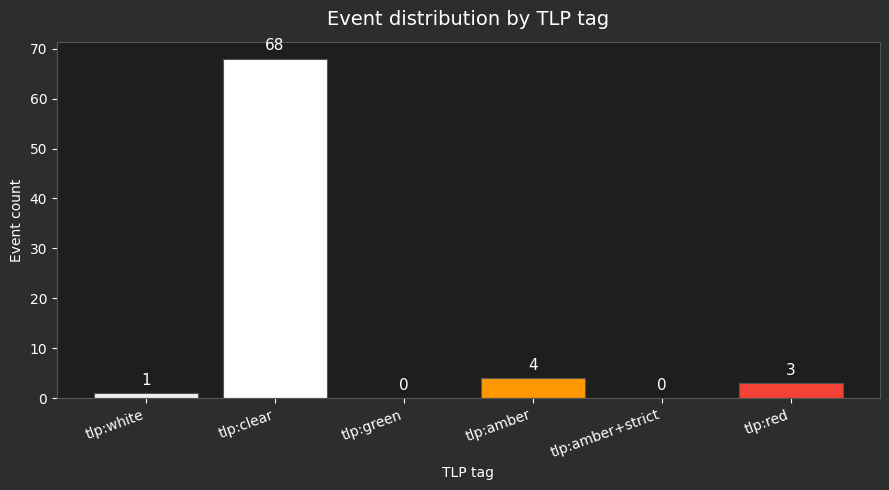

In [9]:
import matplotlib.pyplot as plt

# creating a graph of event counts by TLP tag, using the same color scheme as MISP's UI
tlp_tags = ['tlp:white', 'tlp:clear', 'tlp:green', 'tlp:amber', 'tlp:amber+strict', 'tlp:red']
tlp_colors = {
    'tlp:white':        '#f0f0f0',
    'tlp:clear':        '#ffffff',
    'tlp:green':        '#4caf50',
    'tlp:amber':        '#ff9800',
    'tlp:amber+strict': '#e65100',
    'tlp:red':          '#f44336',
}

counts = {}
for tag in tlp_tags:
    results = misp.search(controller='events', tags=[tag], limit=500)
    counts[tag] = len(results)

labels = list(counts.keys())
values = list(counts.values())
colors = [tlp_colors[t] for t in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='#555555', linewidth=0.8)

ax.bar_label(bars, padding=4, fontsize=11, color='white')
ax.set_title('Event distribution by TLP tag', fontsize=14, pad=12)
ax.set_xlabel('TLP tag')
ax.set_ylabel('Event count')
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#2d2d2d')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


---
## 3. Write
*Turn a threat report's IOC list into a structured MISP event — live*

After running the next cell, **flip to the MISP UI** and show the event appearing.

Richer context: group related indicators with an **Object**, and attribute the activity
with a **Galaxy** cluster (threat actor).

In [11]:
from pymisp import MISPEvent

event = MISPEvent()
event.info          = "DEMO: IOCs from <public report name>"
event.distribution  = 0    # 0 = your org only
event.threat_level_id = 2  # 1 High / 2 Medium / 3 Low / 4 Undefined
event.analysis      = 1    # 0 Initial / 1 Ongoing / 2 Complete

# IOCs lifted straight from the report
event.add_attribute('domain', 'malicious-example.com', to_ids=True)
event.add_attribute('md5',    '44d88612fea8a8f36de82e1278abb02f', to_ids=True)
event.add_attribute('ip-dst', '203.0.113.10', to_ids=True)
event.add_tag('tlp:amber')


created = misp.add_event(event, pythonify=True)
print("Created event:", created.id, created.uuid)

misp.tag(created, 'misp-galaxy:threat-actor="Sofacy"')
print("Object + galaxy tag added to event", created.id)

Created event: 83 d5eba18a-8c8d-4709-a10e-4a8e6c2e0443
Object + galaxy tag added to event 83


In [ ]:
from pymisp import MISPObject

file_obj = MISPObject('file')
file_obj.add_attribute('filename', value='invoice_2026.exe')
file_obj.add_attribute('sha256',   value='275a021bbfb6489e54d471899f7db9d1663fc695ec2fe2a2c4538aabf651fd0f')
misp.add_object(created.id, file_obj)

# Attribute the activity with a Galaxy threat-actor cluster
misp.tag(created, 'misp-galaxy:threat-actor="Sofacy"')
print("Object + galaxy tag added to event", created.id)

In [12]:
from pymisp import MISPObject

file_obj = MISPObject('file')
file_obj.add_attribute('filename', value='invoice_2026.exe')
file_obj.add_attribute('sha256',   value='275a021bbfb6489e54d471899f7db9d1663fc695ec2fe2a2c4538aabf651fd0f')
misp.add_object(created.id, file_obj)
print("File object added to event", created.id)

# Attach a Galaxy cluster so it appears in the Galaxies section of the event UI.
# misp.tag() only adds a string tag; attach_galaxy_cluster() creates the proper
# GalaxyCluster relationship that MISP renders in the Galaxies panel.
galaxies = misp.galaxies(pythonify=True)
ta_galaxy = next((g for g in galaxies if g.type == 'threat-actor'), None)

if ta_galaxy:
    clusters = misp.search_galaxy_clusters(ta_galaxy.id, searchall='Sofacy', pythonify=True)
    if clusters:
        misp.attach_galaxy_cluster(created, clusters[0])
        print(f"Galaxy cluster attached: {clusters[0].value} -> event {created.id}")
    else:
        print("Sofacy cluster not found — check the galaxy is imported on this instance")
else:
    print("threat-actor galaxy not found")


File object added to event 83
Galaxy cluster attached: APT28 -> event 83


---
## 4. Export & Integrate
*From MISP straight to your detection stack*

`return_format` is the killer feature — MISP renders the rules server-side, you just pick the target.

In [ ]:
# IOCs as Suricata rules in a single call
suricata = misp.search(
    controller='attributes',
    tags=['tlp:white'],
    to_ids=True,
    return_format='stix2'
)
pprint.pprint(suricata)

{'type': 'bundle', 'id': 'bundle--065ad619-e804-472a-8435-b5ffe46c3e27', 'objects': [{'type': 'identity', 'spec_version': '2.1', 'id': 'identity--55f6ea65-aa10-4c5a-bf01-4f84950d210f', 'created': '2015-09-14T15:40:21.000Z', 'modified': '2015-09-14T15:40:21.000Z', 'name': 'MISP', 'identity_class': 'organization'}, {'type': 'threat-actor', 'spec_version': '2.1', 'id': 'threat-actor--c01aadc6-1087-4e8e-8d5c-a27eba409fe3', 'created': '2026-04-19T05:39:37.000Z', 'modified': '2026-04-19T05:39:37.000Z', 'name': 'FIN11', 'description': 'FIN11 is a well-established financial crime group that has recently focused its operations on ransomware and extortion. The group has been active since 2017 and has been tracked under UNC902 and later on as TEMP.Warlok. In some ways, FIN11 is reminiscent of APT1; they are notable not for their sophistication, but for their sheer volume of activity.(FireEye) Mandiant has also responded to numerous FIN11 intrusions, but we’ve only observed the group successfully 

In [ ]:
# Other targets: 'snort', 'stix2', 'csv', 'text', 'netfilter', 'json' ...
csv_data = misp.search(controller='attributes', tags=['tlp:white'],
                       return_format='csv')
print(csv_data[:800])

---
## 5. Automate
*A small pipeline that runs itself — the takeaway artifact*

Wrap the previous segments into one reusable function. Drop it in `cron` / a scheduled task
and you have an unattended intel-to-detection feed. **This is the analyst-to-automator jump.**

In [ ]:
def export_fresh_iocs(misp, lookback='1d', outfile='misp_export.rules'):
    """Pull recent detection-flagged network IOCs and write IDS rules."""
    rules = misp.search(
        controller='attributes',
        type_attribute=['ip-dst', 'domain', 'url'],
        to_ids=True,
        date_from=lookback,
        return_format='suricata'
    )
    with open(outfile, 'w') as f:
        f.write(rules)
    print(f"Wrote rules to {outfile} (lookback={lookback})")

export_fresh_iocs(misp)

---
## Appendix — It's just REST
*Everything PyMISP did was this underneath. For any language, or full control.*

In [ ]:
import requests

headers = {'Authorization': MISP_KEY,
           'Accept': 'application/json',
           'Content-Type': 'application/json'}
body = {'returnFormat': 'json', 'type': ['ip-dst'], 'to_ids': 1, 'limit': 5}

r = requests.post(f"{MISP_URL}/attributes/restSearch",
                  headers=headers, json=body, verify=False)
attrs = r.json().get('response', {}).get('Attribute', [])
attrs[0] if attrs else "no results — fetch a feed first"


---
## 🧹 Cleanup (run between takes)
Deletes the demo event created in Section 3 so the instance resets cleanly.

In [ ]:
if created is not None:
    misp.delete_event(created.id)
    print("Deleted demo event", created.id)
    created = None
else:
    print("Nothing to clean up.")